<a href="https://colab.research.google.com/github/sriharithamanikandan/Chatbotpdf/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# INTEGRATED RETAIL ANALYTICS
# EDA + DATA CLEANING + CUSTOMER SEGMENTATION + SENTIMENT ANALYSIS
# ============================================================

!pip -q install wordcloud openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("✅ Dataset uploaded successfully!")

Saving online_retail_II.xlsx to online_retail_II.xlsx
✅ Dataset uploaded successfully!


In [4]:
import pandas as pd

file_name = "online_retail_II.xlsx"

# Excel file load
df = pd.read_excel(file_name)

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

✅ Dataset loaded successfully!
Shape: (525461, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
print("Rows and Columns:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Rows and Columns: (525461, 8)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

Duplicate Rows:
6865


In [6]:
# Check available sheets
excel_file = pd.ExcelFile(file_name)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Year 2009-2010', 'Year 2010-2011']


In [7]:
# Read both sheets
df_2009_2010 = pd.read_excel(file_name, sheet_name="Year 2009-2010")
df_2010_2011 = pd.read_excel(file_name, sheet_name="Year 2010-2011")

# Combine both datasets
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("✅ Both sheets combined!")
print("Final Shape:", df.shape)

display(df.head())

✅ Both sheets combined!
Final Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
print("========== DATASET INFORMATION ==========")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

========== DATASET INFORMATION ==========

Shape:
(1067371, 8)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [9]:
display(df.head(10))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [10]:
display(df.tail(10))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067361,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France
1067362,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France
1067363,581587,22629,SPACEBOY LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France
1067364,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing)

,Missing Values,Missing Percentage
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 34335


In [13]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Missing %": (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    "Unique Values": df.nunique().values
})

display(quality_report)

,Column,Data Type,Missing Values,Missing %,Unique Values
Invoice,Invoice,object,0,0.00,53628
StockCode,StockCode,object,0,0.00,5305
Description,Description,object,4382,0.41,5698
Quantity,Quantity,int64,0,0.00,1057
InvoiceDate,InvoiceDate,datetime64[ns],0,0.00,47635
Price,Price,float64,0,0.00,2807
Customer ID,Customer ID,float64,243007,22.77,5942
Country,Country,object,0,0.00,43


In [14]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [15]:
# InvoiceDate → datetime
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

# Quantity → numeric
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

# Price → numeric
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [16]:
print("Missing values after datatype conversion:")

display(
    df.isnull().sum().to_frame("Missing Values")
)

Missing values after datatype conversion:


,Missing Values
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [17]:
before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 1067371
Rows after removing duplicates: 1033036
Duplicates removed: 34335


In [18]:
before = len(df)

df = df.dropna(subset=["Customer ID"])

after = len(df)

print("Rows removed because Customer ID was missing:", before - after)

Rows removed because Customer ID was missing: 235151


In [19]:
before = len(df)

df = df[df["Quantity"] > 0]

after = len(df)

print("Invalid Quantity rows removed:", before - after)

Invalid Quantity rows removed: 18390


In [20]:
before = len(df)

df = df[df["Price"] > 0]

after = len(df)

print("Invalid Price rows removed:", before - after)

Invalid Price rows removed: 70


In [21]:
df["Revenue"] = df["Quantity"] * df["Price"]

print("✅ Revenue column created!")

display(df.head())

✅ Revenue column created!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [23]:
print("========== FINAL CLEANING REPORT ==========")

# Calculate original rows from the two sheets
original_rows = len(df_2009_2010) + len(df_2010_2011)

print("Original rows:", original_rows)
print("Cleaned rows:", len(df))

print("\nRows removed:", original_rows - len(df))

print("\nDuplicates remaining:", df.duplicated().sum())

print("\nTotal missing values remaining:",
      df.isnull().sum().sum())

print("\nFinal Shape:", df.shape)

========== FINAL CLEANING REPORT ==========
Original rows: 1067371
Cleaned rows: 779425

Rows removed: 287946

Duplicates remaining: 0

Total missing values remaining: 0

Final Shape: (779425, 9)


In [24]:
def iqr_outlier_report(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    }


outlier_results = []

for column in ["Quantity", "Price", "Revenue"]:
    outlier_results.append(
        iqr_outlier_report(df, column)
    )

outlier_report = pd.DataFrame(outlier_results)

display(outlier_report)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.00,12.00,10.00,-13.000,27.000,51119
1,Price,1.25,3.75,2.50,-2.500,7.500,65463
2,Revenue,4.95,19.80,14.85,-17.325,42.075,63562


In [25]:
# TASK 1 - EDA
# Descriptive Statistics

numerical_columns = ["Quantity", "Price", "Revenue"]

stats = df[numerical_columns].describe().T

stats["Median"] = df[numerical_columns].median()

stats["Mode"] = [
    df[column].mode().iloc[0]
    for column in numerical_columns
]

display(stats)

,count,mean,std,min,25%,50%,75%,max,Median,Mode
Quantity,779425.0,13.489370,145.855814,1.000,2.00,6.00,12.00,80995.0,6.00,1.00
Price,779425.0,3.218488,29.676140,0.001,1.25,1.95,3.75,10953.5,1.95,1.25
Revenue,779425.0,22.291823,227.427075,0.001,4.95,12.48,19.80,168469.6,12.48,15.00


In [26]:
# Create time-based columns for EDA

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["Quarter"] = df["InvoiceDate"].dt.to_period("Q").astype(str)
df["Year"] = df["InvoiceDate"].dt.year

print("✅ Month, Quarter and Year columns created!")

display(df[["InvoiceDate", "Month", "Quarter", "Year"]].head())

✅ Month, Quarter and Year columns created!


,InvoiceDate,Month,Quarter,Year
0,2009-12-01 07:45:00,2009-12,2009Q4,2009
1,2009-12-01 07:45:00,2009-12,2009Q4,2009
2,2009-12-01 07:45:00,2009-12,2009Q4,2009
3,2009-12-01 07:45:00,2009-12,2009Q4,2009
4,2009-12-01 07:45:00,2009-12,2009Q4,2009


In [27]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

print("✅ Monthly Revenue calculated!")

display(monthly_sales)

✅ Monthly Revenue calculated!


,Month,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


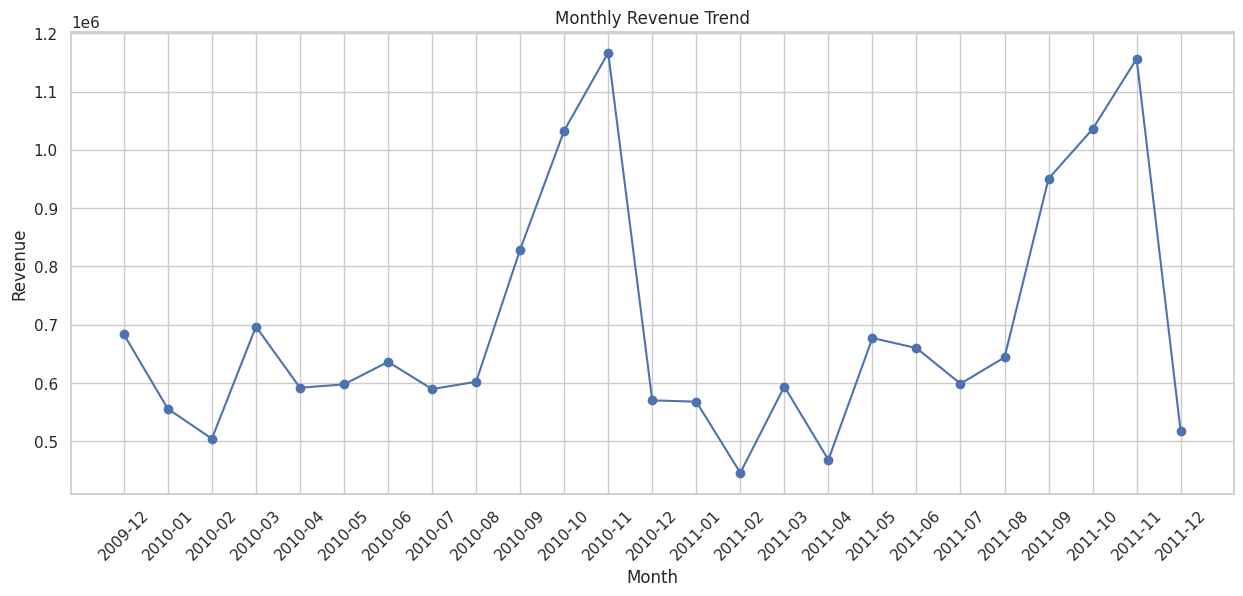

In [28]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [29]:
highest_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

print("========== MONTHLY REVENUE INSIGHT ==========")
print("Highest Revenue Month:", highest_month["Month"])
print("Highest Revenue:", f"{highest_month['Revenue']:,.2f}")

========== MONTHLY REVENUE INSIGHT ==========
Highest Revenue Month: 2010-11
Highest Revenue: 1,166,460.02


In [30]:
quarterly_sales = (
    df.groupby("Quarter")["Revenue"]
      .sum()
      .reset_index()
)

print("✅ Quarterly Revenue calculated!")

display(quarterly_sales)

✅ Quarterly Revenue calculated!


,Quarter,Revenue
0,2009Q4,683504.010
1,2010Q1,1757340.099
2,2010Q2,1826186.512
3,2010Q3,2020974.721
4,2010Q4,2769994.762
5,2011Q1,1608267.990
6,2011Q2,1805775.531
7,2011Q3,2193704.143
8,2011Q4,2709056.500


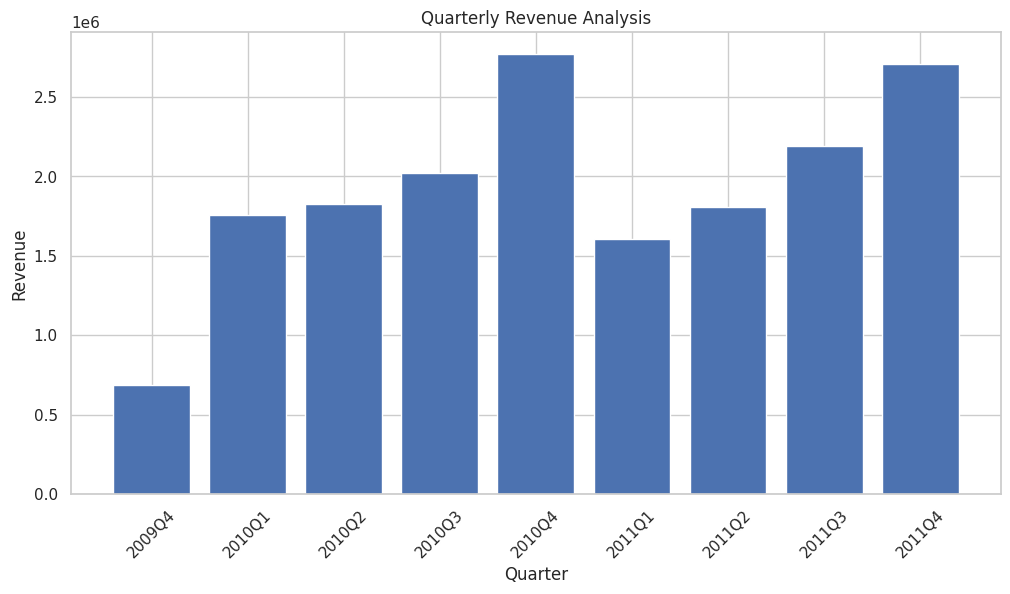

In [31]:
plt.figure(figsize=(12, 6))

plt.bar(
    quarterly_sales["Quarter"],
    quarterly_sales["Revenue"]
)

plt.title("Quarterly Revenue Analysis")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [32]:
highest_quarter = quarterly_sales.loc[
    quarterly_sales["Revenue"].idxmax()
]

print("========== QUARTERLY REVENUE INSIGHT ==========")
print("Highest Revenue Quarter:", highest_quarter["Quarter"])
print("Highest Revenue:", f"{highest_quarter['Revenue']:,.2f}")

========== QUARTERLY REVENUE INSIGHT ==========
Highest Revenue Quarter: 2010Q4
Highest Revenue: 2,769,994.76


In [33]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("========== TOP 10 PRODUCTS BY QUANTITY ==========")

display(top_products)

========== TOP 10 PRODUCTS BY QUANTITY ==========


,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
WHITE HANGING HEART T-LIGHT HOLDER,91757
"PAPER CRAFT , LITTLE BIRDIE",80995
ASSORTED COLOUR BIRD ORNAMENT,78234
MEDIUM CERAMIC TOP STORAGE JAR,77916
JUMBO BAG RED RETROSPOT,74224
BROCADE RING PURSE,70082
PACK OF 60 PINK PAISLEY CAKE CASES,54592
60 TEATIME FAIRY CAKE CASES,52828


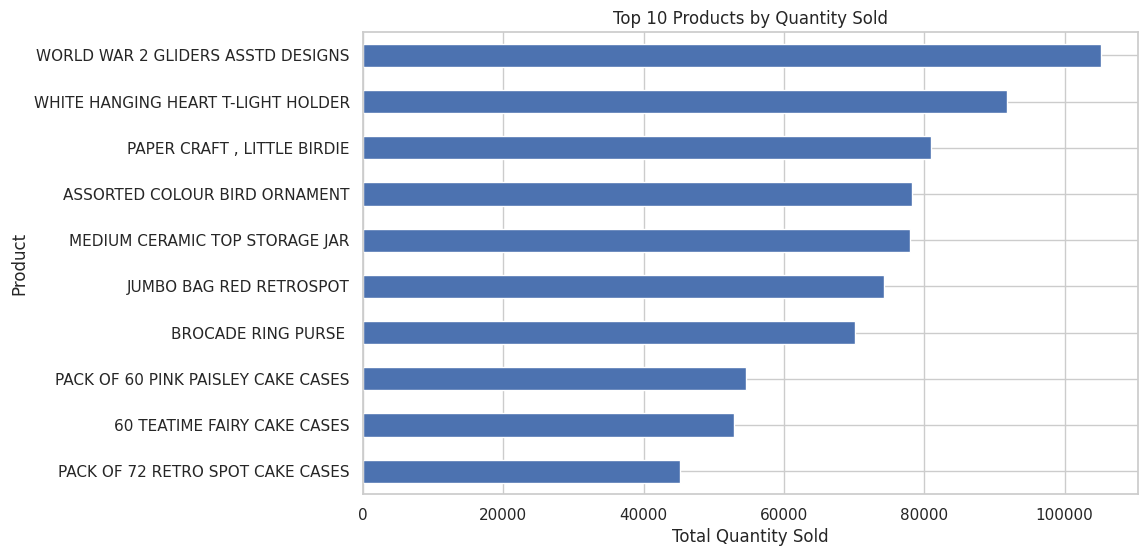

In [34]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.show()

In [35]:
print("Top Product by Quantity:")
print(top_products.index[0])

print("\nQuantity Sold:")
print(top_products.iloc[0])

Top Product by Quantity:
WORLD WAR 2 GLIDERS ASSTD DESIGNS

Quantity Sold:
105185


In [36]:
top_revenue_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("========== TOP 10 PRODUCTS BY REVENUE ==========")
display(top_revenue_products)

========== TOP 10 PRODUCTS BY REVENUE ==========


,Revenue
Description,
REGENCY CAKESTAND 3 TIER,277656.25
WHITE HANGING HEART T-LIGHT HOLDER,247048.01
"PAPER CRAFT , LITTLE BIRDIE",168469.60
Manual,151777.67
JUMBO BAG RED RETROSPOT,134307.44
POSTAGE,124648.04
ASSORTED COLOUR BIRD ORNAMENT,124351.86
PARTY BUNTING,103283.38
MEDIUM CERAMIC TOP STORAGE JAR,81416.73


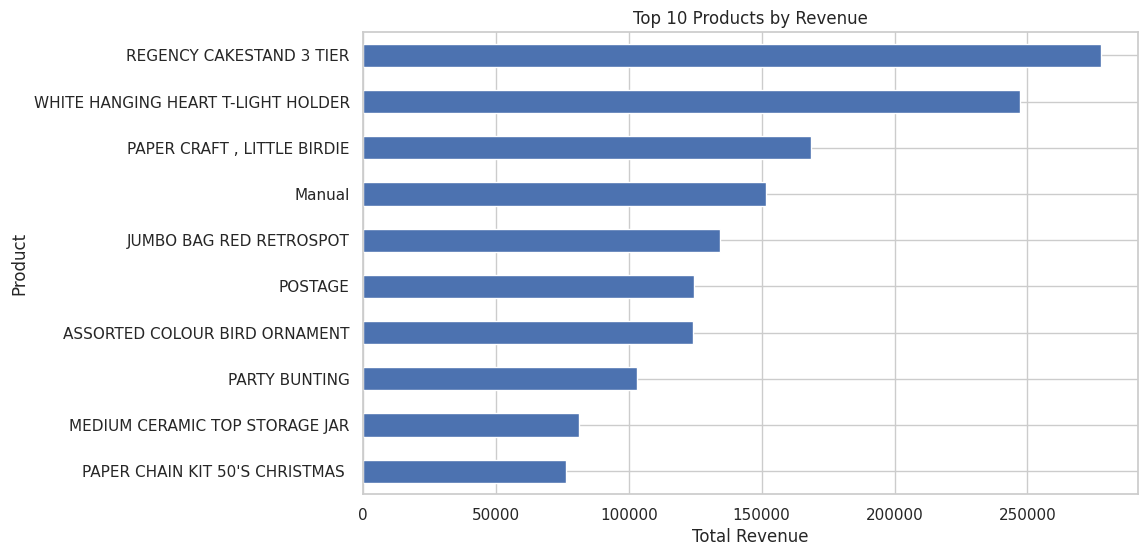

In [37]:
plt.figure(figsize=(10, 6))

top_revenue_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.show()

In [38]:
print("Top Product by Revenue:")
print(top_revenue_products.index[0])

print("\nRevenue:")
print(f"{top_revenue_products.iloc[0]:,.2f}")

Top Product by Revenue:
REGENCY CAKESTAND 3 TIER

Revenue:
277,656.25


In [39]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("========== TOP 10 COUNTRIES BY REVENUE ==========")
display(country_revenue)

========== TOP 10 COUNTRIES BY REVENUE ==========


,Revenue
Country,
United Kingdom,1.438923e+07
EIRE,6.165705e+05
Netherlands,5.540381e+05
Germany,4.250197e+05
France,3.487690e+05
Australia,1.692835e+05
Spain,1.083325e+05
Switzerland,1.000619e+05
Sweden,9.151582e+04


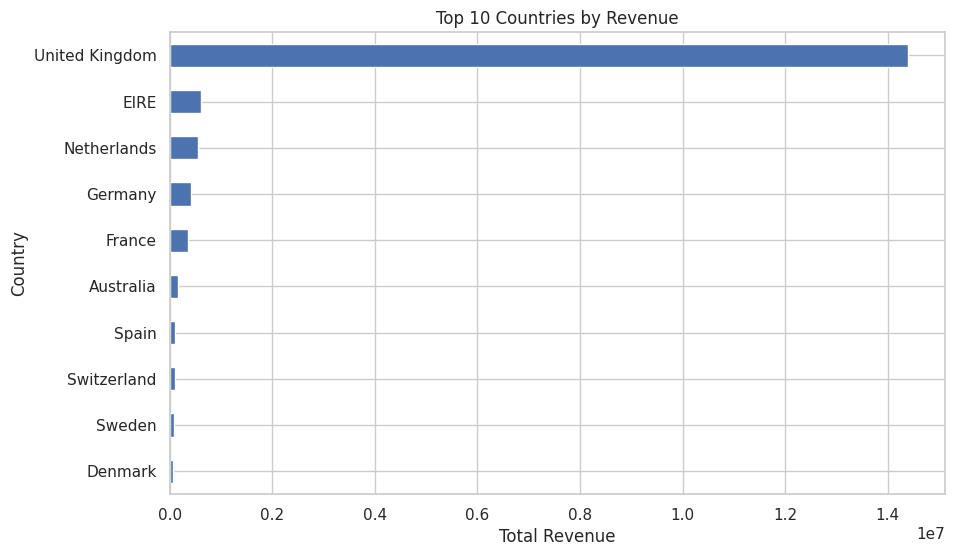

In [40]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.show()

In [41]:
print("Top Country by Revenue:")
print(country_revenue.index[0])

print("\nRevenue:")
print(f"{country_revenue.iloc[0]:,.2f}")

Top Country by Revenue:
United Kingdom

Revenue:
14,389,234.92


In [42]:
correlation = df[["Quantity", "Price", "Revenue"]].corr()

print("========== CORRELATION MATRIX ==========")
display(correlation)

========== CORRELATION MATRIX ==========


,Quantity,Price,Revenue
Quantity,1.000000,-0.004880,0.827162
Price,-0.004880,1.000000,0.135984
Revenue,0.827162,0.135984,1.000000


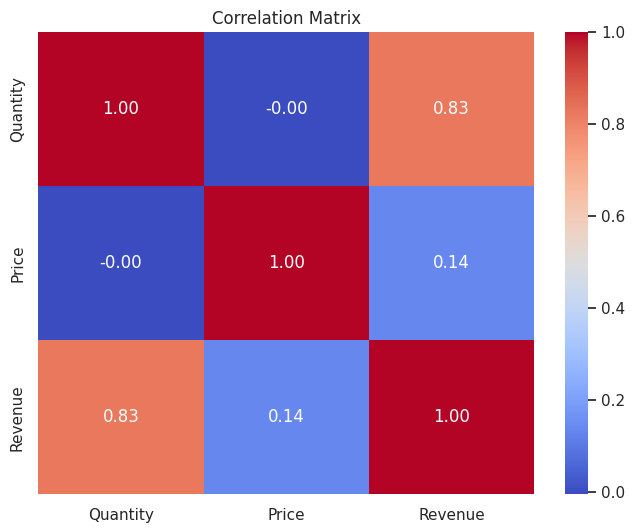

In [43]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

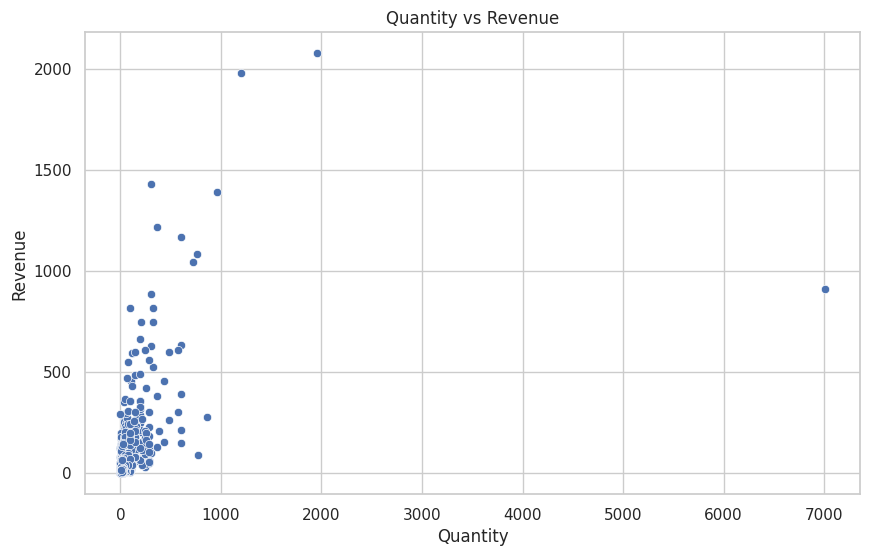

In [44]:
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="Revenue"
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

In [45]:
highest_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

highest_quarter = quarterly_sales.loc[
    quarterly_sales["Revenue"].idxmax()
]

highest_country = country_revenue.index[0]
highest_product_quantity = top_products.index[0]
highest_product_revenue = top_revenue_products.index[0]

print("========== EDA KEY INSIGHTS ==========")

print(f"Highest Revenue Month      : {highest_month['Month']}")
print(f"Highest Monthly Revenue    : {highest_month['Revenue']:,.2f}")

print(f"\nHighest Revenue Quarter    : {highest_quarter['Quarter']}")
print(f"Highest Quarterly Revenue  : {highest_quarter['Revenue']:,.2f}")

print(f"\nTop Country by Revenue      : {highest_country}")
print(f"Top Product by Quantity     : {highest_product_quantity}")
print(f"Top Product by Revenue      : {highest_product_revenue}")

========== EDA KEY INSIGHTS ==========
Highest Revenue Month      : 2010-11
Highest Monthly Revenue    : 1,166,460.02

Highest Revenue Quarter    : 2010Q4
Highest Quarterly Revenue  : 2,769,994.76

Top Country by Revenue      : United Kingdom
Top Product by Quantity     : WORLD WAR 2 GLIDERS ASSTD DESIGNS
Top Product by Revenue      : REGENCY CAKESTAND 3 TIER


In [46]:
print("========================================")
print("       TASK 1 - EDA COMPLETED ✅")
print("========================================")

print("✓ Descriptive Statistics")
print("✓ Monthly Revenue Analysis")
print("✓ Quarterly Revenue Analysis")
print("✓ Top 10 Products by Quantity")
print("✓ Top 10 Products by Revenue")
print("✓ Country-wise Revenue Analysis")
print("✓ Correlation Analysis")
print("✓ Data Visualizations")
print("✓ EDA Key Insights")

       TASK 1 - EDA COMPLETED ✅
✓ Descriptive Statistics
✓ Monthly Revenue Analysis
✓ Quarterly Revenue Analysis
✓ Top 10 Products by Quantity
✓ Top 10 Products by Revenue
✓ Country-wise Revenue Analysis
✓ Correlation Analysis
✓ Data Visualizations
✓ EDA Key Insights


In [47]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm = rfm.reset_index()

print("========== RFM TABLE ==========")
display(rfm.head())
print("\nNumber of Customers:", len(rfm))

========== RFM TABLE ==========


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40



Number of Customers: 5878


In [48]:
rfm["Average_Purchase_Value"] = (
    rfm["Monetary"] / rfm["Frequency"]
)

print("========== RFM WITH AVERAGE PURCHASE VALUE ==========")
display(rfm.head())

========== RFM WITH AVERAGE PURCHASE VALUE ==========


,Customer ID,Recency,Frequency,Monetary,Average_Purchase_Value
0,12346.0,326,12,77556.46,6463.038333
1,12347.0,2,8,4921.53,615.191250
2,12348.0,75,5,2019.40,403.880000
3,12349.0,19,4,4428.69,1107.172500
4,12350.0,310,1,334.40,334.400000


In [49]:
print("========== RFM STATISTICS ==========")
display(
    rfm[
        ["Recency", "Frequency", "Monetary",
         "Average_Purchase_Value"]
    ].describe()
)

========== RFM STATISTICS ==========


,Recency,Frequency,Monetary,Average_Purchase_Value
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095,385.180841
std,209.338707,13.009406,14440.852688,1214.286459
min,1.000000,1.000000,2.950000,2.950000
25%,26.000000,1.000000,342.280000,176.682500
50%,96.000000,3.000000,867.740000,279.242679
75%,380.000000,7.000000,2248.305000,414.902458
max,739.000000,398.000000,580987.040000,84236.250000


In [50]:
from sklearn.preprocessing import StandardScaler

rfm_features = [
    "Recency",
    "Frequency",
    "Monetary"
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[rfm_features]
)

print("✅ RFM data standardized successfully!")

print("Original shape:", rfm[rfm_features].shape)
print("Scaled shape:", rfm_scaled.shape)

✅ RFM data standardized successfully!
Original shape: (5878, 3)
Scaled shape: (5878, 3)


In [51]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features
)

display(rfm_scaled_df.head())

,Recency,Frequency,Monetary
0,0.595584,0.438998,5.166378
1,-0.952279,0.131502,0.136127
2,-0.603532,-0.099120,-0.064857
3,-0.871064,-0.175994,0.101996
4,0.519146,-0.406616,-0.181549


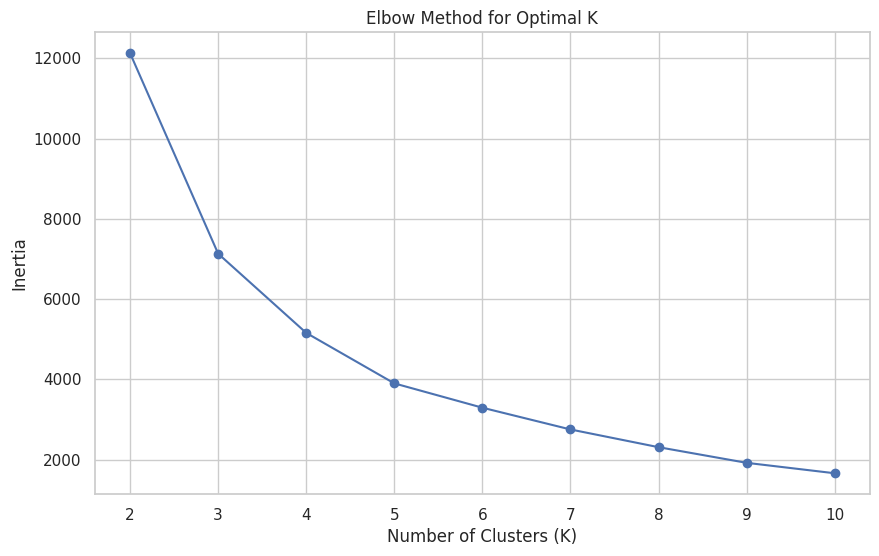

In [52]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.grid(True)
plt.show()

In [53]:
optimal_k = 4

print("Selected Number of Clusters (K):", optimal_k)

Selected Number of Clusters (K): 4


In [54]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("✅ Customer segmentation completed!")

display(rfm.head())

✅ Customer segmentation completed!


,Customer ID,Recency,Frequency,Monetary,Average_Purchase_Value,Cluster
0,12346.0,326,12,77556.46,6463.038333,0
1,12347.0,2,8,4921.53,615.191250,0
2,12348.0,75,5,2019.40,403.880000,0
3,12349.0,19,4,4428.69,1107.172500,0
4,12350.0,310,1,334.40,334.400000,1


In [55]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print("========== CUSTOMERS IN EACH CLUSTER ==========")
display(cluster_counts)

========== CUSTOMERS IN EACH CLUSTER ==========


,count
Cluster,
0,3838
1,1998
2,4
3,38


In [56]:
cluster_profile = (
    rfm.groupby("Cluster")[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Average_Purchase_Value"
        ]
    ]
    .mean()
    .round(2)
)

print("========== CUSTOMER SEGMENT PROFILE ==========")
display(cluster_profile)

========== CUSTOMER SEGMENT PROFILE ==========


,Recency,Frequency,Monetary,Average_Purchase_Value
Cluster,,,,
0,67.05,7.27,2921.08,380.34
1,463.03,2.21,748.54,336.06
2,3.50,212.50,428612.00,2562.23
3,24.26,100.13,77728.27,3228.18


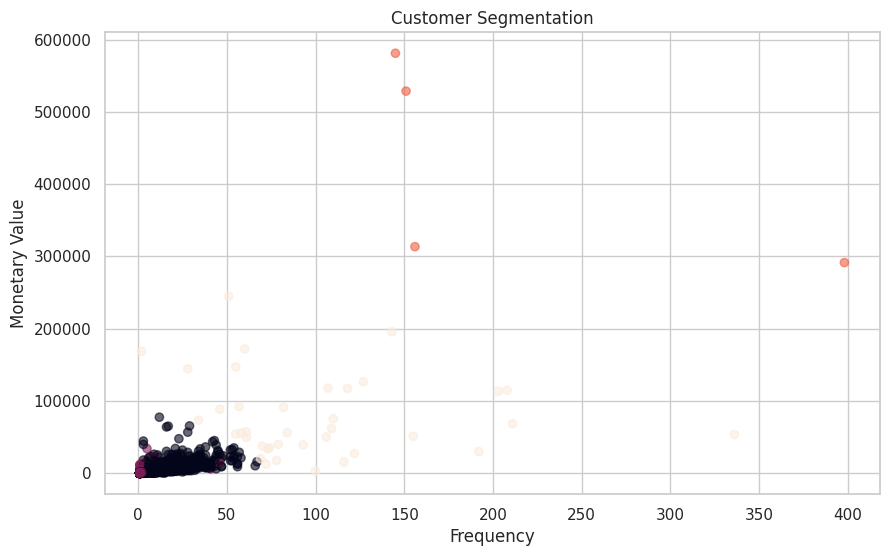

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.title("Customer Segmentation")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.show()

In [58]:
print("========== CLUSTER SUMMARY ==========")

for cluster in sorted(rfm["Cluster"].unique()):
    data = rfm[rfm["Cluster"] == cluster]

    print(f"\nCluster {cluster}")
    print("-" * 30)
    print("Customers:", len(data))
    print("Average Recency:", round(data["Recency"].mean(), 2))
    print("Average Frequency:", round(data["Frequency"].mean(), 2))
    print("Average Monetary:", round(data["Monetary"].mean(), 2))

========== CLUSTER SUMMARY ==========

Cluster 0
------------------------------
Customers: 3838
Average Recency: 67.05
Average Frequency: 7.27
Average Monetary: 2921.08

Cluster 1
------------------------------
Customers: 1998
Average Recency: 463.03
Average Frequency: 2.21
Average Monetary: 748.54

Cluster 2
------------------------------
Customers: 4
Average Recency: 3.5
Average Frequency: 212.5
Average Monetary: 428612.0

Cluster 3
------------------------------
Customers: 38
Average Recency: 24.26
Average Frequency: 100.13
Average Monetary: 77728.27


In [59]:
cluster_profile = (
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

print("========== CLUSTER INTERPRETATION ==========")

for cluster in cluster_profile.index:
    recency = cluster_profile.loc[cluster, "Recency"]
    frequency = cluster_profile.loc[cluster, "Frequency"]
    monetary = cluster_profile.loc[cluster, "Monetary"]

    print(f"\nCluster {cluster}")
    print(f"Recency  : {recency}")
    print(f"Frequency: {frequency}")
    print(f"Monetary : {monetary}")

========== CLUSTER INTERPRETATION ==========

Cluster 0
Recency  : 67.05
Frequency: 7.27
Monetary : 2921.08

Cluster 1
Recency  : 463.03
Frequency: 2.21
Monetary : 748.54

Cluster 2
Recency  : 3.5
Frequency: 212.5
Monetary : 428612.0

Cluster 3
Recency  : 24.26
Frequency: 100.13
Monetary : 77728.27


In [60]:
rfm.to_csv("customer_segments.csv", index=False)

print("✅ Customer segmentation file saved!")
print("File name: customer_segments.csv")

✅ Customer segmentation file saved!
File name: customer_segments.csv


In [61]:
from google.colab import files

files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
from google.colab import files

uploaded_reviews = files.upload()

print("✅ Review dataset uploaded!")
print("File name:", list(uploaded_reviews.keys())[0])

Saving customer_segments.csv to customer_segments (1).csv
✅ Review dataset uploaded!
File name: customer_segments (1).csv


In [64]:
import pandas as pd

review_file = "customer_segments (1).csv"

reviews = pd.read_csv(review_file)

print("Shape:", reviews.shape)

print("\nColumns:")
print(reviews.columns.tolist())

print("\nFirst 5 rows:")
display(reviews.head())

Shape: (5878, 6)

Columns:
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Average_Purchase_Value', 'Cluster']

First 5 rows:


,Customer ID,Recency,Frequency,Monetary,Average_Purchase_Value,Cluster
0,12346.0,326,12,77556.46,6463.038333,0
1,12347.0,2,8,4921.53,615.191250,0
2,12348.0,75,5,2019.40,403.880000,0
3,12349.0,19,4,4428.69,1107.172500,0
4,12350.0,310,1,334.40,334.400000,1


In [65]:
from google.colab import files

print("📂 Please upload your REVIEW dataset (CSV)...")

uploaded = files.upload()

review_file = list(uploaded.keys())[0]

print("\n✅ Review dataset uploaded!")
print("File name:", review_file)

📂 Please upload your REVIEW dataset (CSV)...


Saving amazon_cells_labelled.txt to amazon_cells_labelled.txt

✅ Review dataset uploaded!
File name: amazon_cells_labelled.txt


In [66]:
import pandas as pd

review_file = "amazon_cells_labelled.txt"

reviews = pd.read_csv(
    review_file,
    sep="\t",
    header=None,
    names=["Review", "Sentiment"]
)

print("========== DATASET INFORMATION ==========")
print("Shape:", reviews.shape)

print("\nColumns:")
print(reviews.columns.tolist())

print("\nFirst 10 Reviews:")
display(reviews.head(10))

========== DATASET INFORMATION ==========
Shape: (1000, 2)

Columns:
['Review', 'Sentiment']

First 10 Reviews:


,Review,Sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,1
8,"Needless to say, I wasted my money.",0
9,What a waste of money and time!.,0


In [67]:
# Sentiment Distribution

print("========== SENTIMENT DISTRIBUTION ==========")

sentiment_counts = reviews["Sentiment"].value_counts().sort_index()

display(sentiment_counts)

print("\n0 = Negative")
print("1 = Positive")


========== SENTIMENT DISTRIBUTION ==========


,count
Sentiment,
0,500
1,500



0 = Negative
1 = Positive


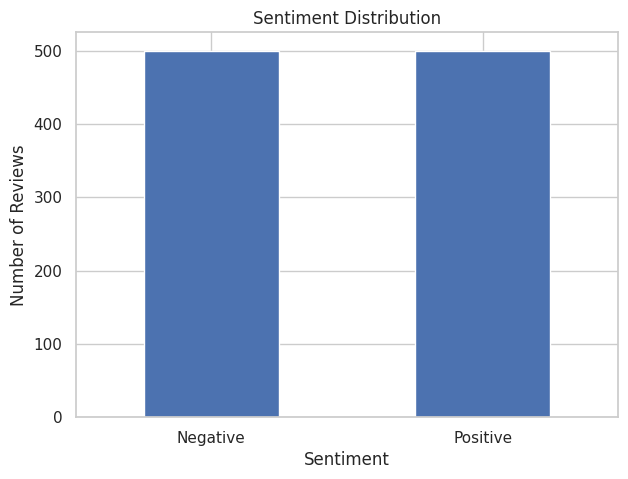

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sentiment_counts.plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
    rotation=0
)

plt.show()

In [69]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

reviews["Cleaned_Review"] = reviews["Review"].apply(clean_text)

print("========== TEXT CLEANING COMPLETED ==========")
display(
    reviews[["Review", "Cleaned_Review", "Sentiment"]].head(10)
)

========== TEXT CLEANING COMPLETED ==========


,Review,Cleaned_Review,Sentiment
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great for the jawbone,1
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...,0
4,The mic is great.,the mic is great,1
5,I have to jiggle the plug to get it to line up...,i have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,if you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,if you are razr owneryou must have this,1
8,"Needless to say, I wasted my money.",needless to say i wasted my money,0
9,What a waste of money and time!.,what a waste of money and time,0


In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = tfidf.fit_transform(reviews["Cleaned_Review"])
y = reviews["Sentiment"]

print("========== TF-IDF FEATURE EXTRACTION ==========")
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

========== TF-IDF FEATURE EXTRACTION ==========
Feature Matrix Shape: (1000, 1687)
Target Shape: (1000,)


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("========== TRAIN / TEST SPLIT ==========")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

========== TRAIN / TEST SPLIT ==========
Training samples: 800
Testing samples : 200
Training features: 1687
Testing features : 1687


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

# Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("========== MODEL TRAINING COMPLETED ==========")
print("✓ Logistic Regression trained")
print("✓ Naive Bayes trained")

========== MODEL TRAINING COMPLETED ==========
✓ Logistic Regression trained
✓ Naive Bayes trained


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
logistic_pred = logistic_model.predict(X_test)
nb_pred = nb_model.predict(X_test)

# Metrics
logistic_metrics = [
    accuracy_score(y_test, logistic_pred),
    precision_score(y_test, logistic_pred),
    recall_score(y_test, logistic_pred),
    f1_score(y_test, logistic_pred)
]

nb_metrics = [
    accuracy_score(y_test, nb_pred),
    precision_score(y_test, nb_pred),
    recall_score(y_test, nb_pred),
    f1_score(y_test, nb_pred)
]

# Comparison table
comparison = pd.DataFrame(
    [logistic_metrics, nb_metrics],
    columns=["Accuracy", "Precision", "Recall", "F1-Score"],
    index=["Logistic Regression", "Naive Bayes"]
)

print("========== MODEL EVALUATION ==========")
display(comparison.round(4))

print("\n===== Logistic Regression =====")
print(classification_report(y_test, logistic_pred))

print("\n===== Naive Bayes =====")
print(classification_report(y_test, nb_pred))

========== MODEL EVALUATION ==========


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.780,0.8333,0.70,0.7609
Naive Bayes,0.755,0.7179,0.84,0.7742



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.74      0.86      0.80       100
           1       0.83      0.70      0.76       100

    accuracy                           0.78       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.78      0.78       200


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.81      0.67      0.73       100
           1       0.72      0.84      0.77       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



===== Logistic Regression Confusion Matrix =====
[[86 14]
 [30 70]]


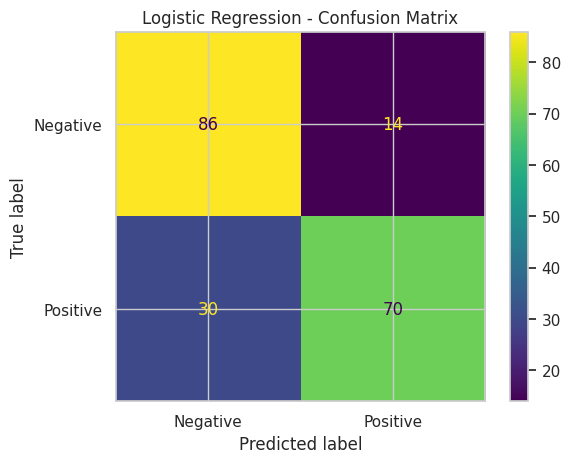

===== Naive Bayes Confusion Matrix =====
[[67 33]
 [16 84]]


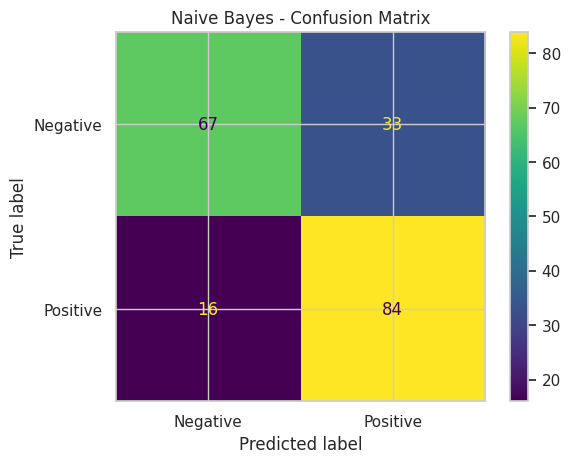

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix - Logistic Regression
cm_logistic = confusion_matrix(y_test, logistic_pred)

print("===== Logistic Regression Confusion Matrix =====")
print(cm_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Confusion Matrix - Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred)

print("===== Naive Bayes Confusion Matrix =====")
print(cm_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [75]:
# Actual vs Predicted Sentiment

results = pd.DataFrame({
    "Review": reviews.loc[y_test.index, "Review"].values,
    "Actual": y_test.values,
    "Predicted": logistic_pred
})

results["Actual_Label"] = results["Actual"].map({
    0: "Negative",
    1: "Positive"
})

results["Predicted_Label"] = results["Predicted"].map({
    0: "Negative",
    1: "Positive"
})

print("========== ACTUAL VS PREDICTED ==========")
display(
    results[
        ["Review", "Actual_Label", "Predicted_Label"]
    ].head(20)
)

========== ACTUAL VS PREDICTED ==========


,Review,Actual_Label,Predicted_Label
0,"Five star Plus, plus.",Positive,Negative
1,It doesn't work in Europe or Asia.,Negative,Negative
2,BT50 battery junk!.,Negative,Negative
3,i got this phone around the end of may and i'm...,Negative,Positive
4,"Simple, lightweight and great fit.",Positive,Positive
5,nice leather.,Positive,Positive
6,Nice design and quality.,Positive,Positive
7,"Excellent sound, battery life and inconspicuou...",Positive,Positive
8,I've had this bluetoooth headset for some time...,Negative,Positive
9,worthless product.,Negative,Negative


In [76]:
# Save sentiment analysis results

results.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print("========================================")
print("   TASK 4 - SENTIMENT ANALYSIS DONE ✅")
print("========================================")

print("✓ Review Dataset Loaded")
print("✓ Sentiment Distribution")
print("✓ Text Cleaning")
print("✓ TF-IDF Feature Extraction")
print("✓ Train/Test Split")
print("✓ Logistic Regression")
print("✓ Naive Bayes")
print("✓ Accuracy, Precision, Recall, F1-Score")
print("✓ Confusion Matrix")
print("✓ Actual vs Predicted Analysis")
print("✓ Results Saved")

print("\nFile: sentiment_analysis_results.csv")
print("Rows:", len(results))

   TASK 4 - SENTIMENT ANALYSIS DONE ✅
✓ Review Dataset Loaded
✓ Sentiment Distribution
✓ Text Cleaning
✓ TF-IDF Feature Extraction
✓ Train/Test Split
✓ Logistic Regression
✓ Naive Bayes
✓ Accuracy, Precision, Recall, F1-Score
✓ Confusion Matrix
✓ Actual vs Predicted Analysis
✓ Results Saved

File: sentiment_analysis_results.csv
Rows: 200


In [77]:
from google.colab import files

files.download("sentiment_analysis_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
print("====================================================")
print("        INTEGRATED RETAIL ANALYTICS PROJECT")
print("====================================================")

print("\nTASK 1 - EDA")
print("✓ Descriptive Statistics")
print("✓ Monthly & Quarterly Revenue")
print("✓ Top Products")
print("✓ Country-wise Revenue")
print("✓ Correlation Analysis")

print("\nTASK 2 - CUSTOMER SEGMENTATION")
print("✓ RFM Analysis")
print("✓ Customer Features")
print("✓ K-Means Clustering")
print("✓ Customer Segments")

print("\nTASK 3 - DATA CLEANING")
print("✓ Duplicate Removal")
print("✓ Missing Value Handling")
print("✓ Invalid Quantity Removal")
print("✓ Invalid Price Removal")
print("✓ Outlier Analysis")
print("✓ Revenue Feature Creation")

print("\nTASK 4 - SENTIMENT ANALYSIS")
print("✓ Text Cleaning")
print("✓ TF-IDF")
print("✓ Logistic Regression")
print("✓ Naive Bayes")
print("✓ Model Evaluation")
print("✓ Confusion Matrix")
print("✓ Actual vs Predicted")

print("\n====================================================")
print("             PROJECT COMPLETED ✅")
print("====================================================")

        INTEGRATED RETAIL ANALYTICS PROJECT

TASK 1 - EDA
✓ Descriptive Statistics
✓ Monthly & Quarterly Revenue
✓ Top Products
✓ Country-wise Revenue
✓ Correlation Analysis

TASK 2 - CUSTOMER SEGMENTATION
✓ RFM Analysis
✓ Customer Features
✓ K-Means Clustering
✓ Customer Segments

TASK 3 - DATA CLEANING
✓ Duplicate Removal
✓ Missing Value Handling
✓ Invalid Quantity Removal
✓ Invalid Price Removal
✓ Outlier Analysis
✓ Revenue Feature Creation

TASK 4 - SENTIMENT ANALYSIS
✓ Text Cleaning
✓ TF-IDF
✓ Logistic Regression
✓ Naive Bayes
✓ Model Evaluation
✓ Confusion Matrix
✓ Actual vs Predicted

             PROJECT COMPLETED ✅
